## Bootstrapping
Textbook reference: Chapter 13.2 
Link: https://inferentialthinking.com/chapters/13/2/Bootstrap.html


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
x=[1,2,3,4,5,6]
df=pd.DataFrame(x)
df

,0
0,1
1,2
2,3
3,4
4,5
5,6


In [3]:
sam=df.sample(6,replace=True)
sam

,0
1,2
4,5
4,5
5,6
2,3
1,2


### Estimate the median of salaries of population in San Francisco

In [4]:
emp=pd.read_csv("san_francisco_2019.csv")
emp

,Organization Group,Department,Job Family,Job,Salary,Overtime,Benefits,Total Compensation
0,Public Protection,Adult Probation,Information Systems,IS Trainer-Journey,91332.0,0.0,40059.0,131391.0
1,Public Protection,Adult Probation,Information Systems,IS Engineer-Assistant,123241.0,0.0,49279.0,172520.0
2,Public Protection,Adult Probation,Information Systems,IS Business Analyst-Senior,115715.0,0.0,46752.0,162468.0
3,Public Protection,Adult Probation,Information Systems,IS Business Analyst-Principal,159394.0,0.0,57312.0,216706.0
4,Public Protection,Adult Probation,Information Systems,IS Programmer Analyst,70035.0,0.0,28671.0,98706.0
...,...,...,...,...,...,...,...,...
44520,General Administration & Finance,Treasurer/Tax Collector,Revenue,"Investigator, Tax Collector",44961.0,42.0,19546.0,64549.0
44521,General Administration & Finance,Treasurer/Tax Collector,Revenue,"Investigator, Tax Collector",85706.0,107.0,38924.0,124737.0
44522,General Administration & Finance,Treasurer/Tax Collector,Revenue,"Investigator, Tax Collector",101403.0,0.0,43185.0,144587.0
44523,General Administration & Finance,Treasurer/Tax Collector,Revenue,"Pr Investigator, Tax Collector",113738.0,397.0,47104.0,161240.0


In [5]:
emp.head()

,Organization Group,Department,Job Family,Job,Salary,Overtime,Benefits,Total Compensation
0,Public Protection,Adult Probation,Information Systems,IS Trainer-Journey,91332.0,0.0,40059.0,131391.0
1,Public Protection,Adult Probation,Information Systems,IS Engineer-Assistant,123241.0,0.0,49279.0,172520.0
2,Public Protection,Adult Probation,Information Systems,IS Business Analyst-Senior,115715.0,0.0,46752.0,162468.0
3,Public Protection,Adult Probation,Information Systems,IS Business Analyst-Principal,159394.0,0.0,57312.0,216706.0
4,Public Protection,Adult Probation,Information Systems,IS Programmer Analyst,70035.0,0.0,28671.0,98706.0


In [6]:
emp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44525 entries, 0 to 44524
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Organization Group  44525 non-null  object 
 1   Department          44525 non-null  object 
 2   Job Family          44525 non-null  object 
 3   Job                 44525 non-null  object 
 4   Salary              44525 non-null  float64
 5   Overtime            44525 non-null  float64
 6   Benefits            44525 non-null  float64
 7   Total Compensation  44525 non-null  float64
dtypes: float64(4), object(4)
memory usage: 2.7+ MB


In [7]:
emp.describe()

,Salary,Overtime,Benefits,Total Compensation
count,44525.000000,44525.000000,44525.000000,44525.000000
mean,80608.707602,7193.630679,32039.964986,119842.301494
std,54902.440903,16047.788821,20057.175516,79868.070136
min,-338.000000,-46.000000,0.000000,0.000000
25%,36132.000000,0.000000,13955.000000,53002.000000
50%,79444.000000,78.000000,36429.000000,121630.000000
75%,115493.000000,6449.000000,45744.000000,172834.000000
max,577633.000000,315896.000000,146398.000000,724031.000000


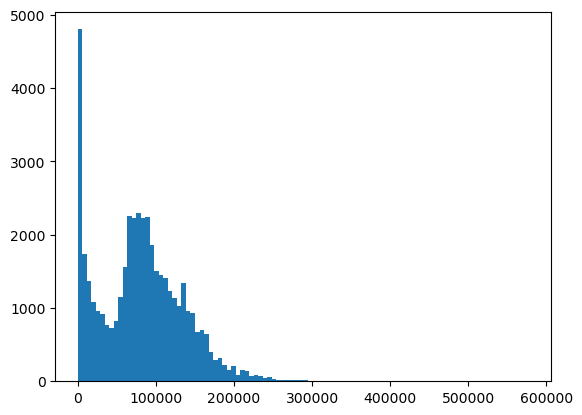

In [12]:
plt.hist(emp["Salary"],bins=100)
plt.show()

#### Lets imagine this is the population, and take a random sample of size 1000 from this population.

In [16]:
rs=emp.sample(1000)

In [17]:
rs

,Organization Group,Department,Job Family,Job,Salary,Overtime,Benefits,Total Compensation
12482,"Public Works, Transportation & Commerce",Department Of Public Works,"Budget, Admn & Stats Analysis",Junior Administrative Analyst,62520.0,1531.0,27764.0,91815.0
2207,Public Protection,Fire Department,Fire Services,Firefighter,75087.0,2115.0,32332.0,109535.0
17018,"Public Works, Transportation & Commerce",Municipal Transportation Agcy,Street Transit,Transit Operator,64210.0,8969.0,37020.0,110199.0
43534,General Administration & Finance,Registrar,"Clerical, Secretarial & Steno",Junior Clerk,956.0,443.0,109.0,1507.0
9763,"Public Works, Transportation & Commerce",Airport Commission,Housekeeping & Laundry,Custodian,54356.0,1158.0,27728.0,83242.0
...,...,...,...,...,...,...,...,...
26231,Human Welfare & Neighborhood Development,Human Services,Public Service Aide,Public Service Trainee,20391.0,0.0,2451.0,22842.0
7125,Public Protection,Police,Police Services,Lieutenant 3,187001.0,28382.0,51847.0,267230.0
23293,Human Welfare & Neighborhood Development,Human Services,Information Systems,IS Business Analyst-Senior,127852.0,0.0,49515.0,177367.0
10583,"Public Works, Transportation & Commerce",Building Inspection,Public Safety Inspection,Housing Inspector,120924.0,9.0,48855.0,169788.0


In [18]:
rs["Salary"].median()

81527.0

Text(0.5, 1.0, 'Random sample')

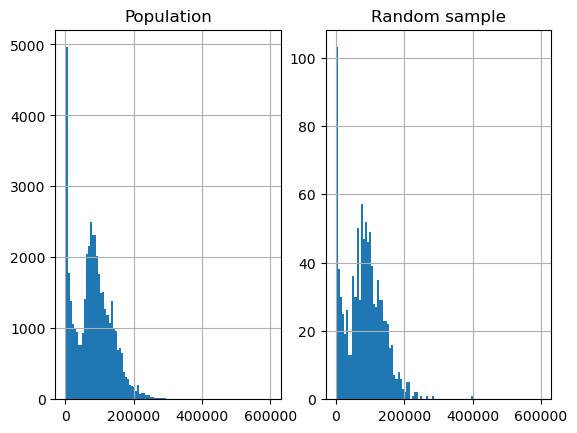

In [19]:
plt.figure()
plt.subplot(121)
emp["Salary"].hist(bins=100,range=(0,600000))
plt.title("Population")
plt.subplot(122)
rs["Salary"].hist(bins=100,range=(0,600000))
plt.title("Random sample")

#### Lets do bootstrapping and make some re-samples!

In [20]:
rs1=rs.sample(1000, replace=True)
rs2=rs.sample(1000, replace=True)
rs3=rs.sample(1000, replace=True)

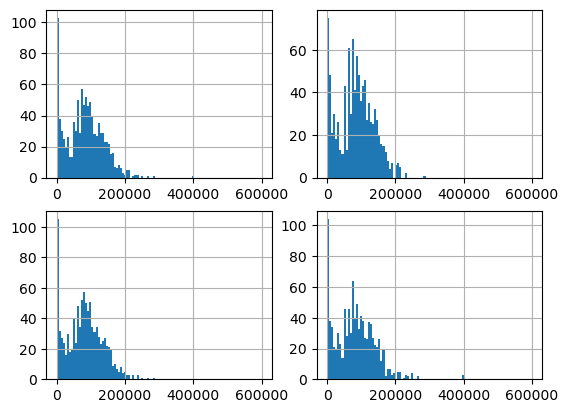

In [21]:
plt.figure()
plt.subplot(221)
rs["Salary"].hist(bins=100,range=(0,600000))
plt.subplot(222)
rs1["Salary"].hist(bins=100,range=(0,600000))
plt.subplot(223)
rs2["Salary"].hist(bins=100,range=(0,600000))
plt.subplot(224)
rs3["Salary"].hist(bins=100,range=(0,600000))
plt.show()

#### In the above plots, note the similarities in the patterns of the distributions from different re-samples created from the original random sample

In [22]:
rs1["Salary"].median()

85236.0

In [23]:
rs2["Salary"].median()

81015.0

In [24]:
rs3["Salary"].median()

78545.0

In [25]:
nsim=10000
medians=[]
for i in range(nsim):
    rsi=rs.sample(1000, replace=True)
    medians.append(rsi["Salary"].median())

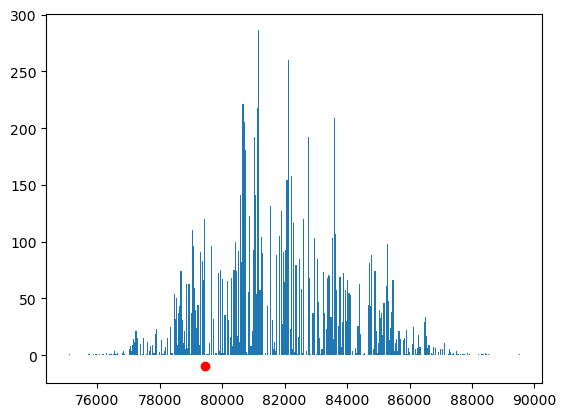

In [26]:
plt.figure()
plt.hist(medians,bins=400)
plt.scatter(emp["Salary"].median(),-10,color="Red")
plt.show()


In [27]:
left=np.percentile(medians,2.5)
left

78257.0

In [28]:
right=np.percentile(medians,97.5)
right

85907.0

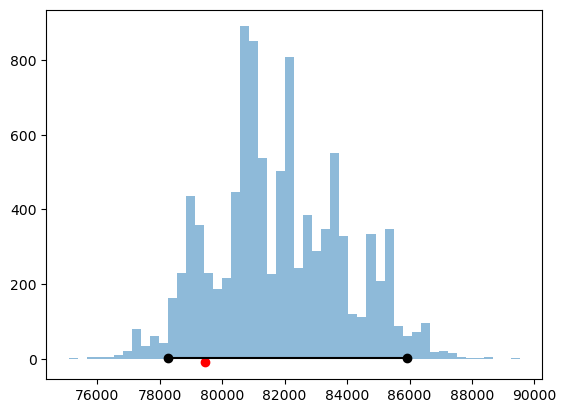

In [29]:
pop_mdn=emp["Salary"].median()
plt.figure()
plt.hist(medians,bins=50,alpha=0.5)
plt.scatter(pop_mdn,-10,color="Red")
plt.plot([left,right],[1,1],color="black",marker="o")
plt.show()

In [30]:
estimates=[]
for i in range(100):
    rs=emp.sample(1000)
    nsim=10000
    medians=[]
    for n in range(nsim):
        rsn=rs.sample(1000, replace=True)
        medians.append(rsn["Salary"].median())
    left=np.percentile(medians,2.5)
    right=np.percentile(medians,97.5)
    rng=[left,right]
    print("estimate %i  :"%i,rng)
    estimates.append(rng)

estimate 0  : [79771.775, 86342.5]
estimate 1  : [80034.0, 86327.5]
estimate 2  : [75439.0, 81825.5]
estimate 3  : [75057.5, 82845.5]
estimate 4  : [77857.0, 84909.0]
estimate 5  : [78513.0, 84975.0]
estimate 6  : [77068.0, 83342.0]
estimate 7  : [76837.0, 83425.0]
estimate 8  : [79442.5, 85456.0]
estimate 9  : [74046.0, 80569.5]
estimate 10  : [76042.55, 85953.0]
estimate 11  : [74036.0, 81082.0]
estimate 12  : [79502.0, 87233.0]
estimate 13  : [77047.0, 82905.0]
estimate 14  : [76603.5, 83341.11249999997]
estimate 15  : [76441.0, 84593.5]
estimate 16  : [77054.0, 83567.5]
estimate 17  : [75808.0, 83339.0]
estimate 18  : [75510.7125, 83248.0]
estimate 19  : [74593.75, 82028.0]
estimate 20  : [77098.0, 85429.3875]
estimate 21  : [74609.5, 82589.5]
estimate 22  : [74256.0, 81084.19999999998]
estimate 23  : [76026.0, 82837.0]
estimate 24  : [76098.5, 82592.5]
estimate 25  : [78430.0, 85485.0]
estimate 26  : [75590.0, 82260.5]
estimate 27  : [79481.5, 85372.0]
estimate 28  : [80757.5, 874

In [31]:
est_range=np.array(estimates)
est_range

array([[79771.775 , 86342.5   ],
       [80034.    , 86327.5   ],
       [75439.    , 81825.5   ],
       [75057.5   , 82845.5   ],
       [77857.    , 84909.    ],
       [78513.    , 84975.    ],
       [77068.    , 83342.    ],
       [76837.    , 83425.    ],
       [79442.5   , 85456.    ],
       [74046.    , 80569.5   ],
       [76042.55  , 85953.    ],
       [74036.    , 81082.    ],
       [79502.    , 87233.    ],
       [77047.    , 82905.    ],
       [76603.5   , 83341.1125],
       [76441.    , 84593.5   ],
       [77054.    , 83567.5   ],
       [75808.    , 83339.    ],
       [75510.7125, 83248.    ],
       [74593.75  , 82028.    ],
       [77098.    , 85429.3875],
       [74609.5   , 82589.5   ],
       [74256.    , 81084.2   ],
       [76026.    , 82837.    ],
       [76098.5   , 82592.5   ],
       [78430.    , 85485.    ],
       [75590.    , 82260.5   ],
       [79481.5   , 85372.    ],
       [80757.5   , 87442.    ],
       [75573.    , 81335.775 ],
       [74

In [32]:
prcnt=np.count_nonzero((est_range[:,1]>pop_mdn)&(est_range[:,0]<pop_mdn))

In [33]:
prcnt

90

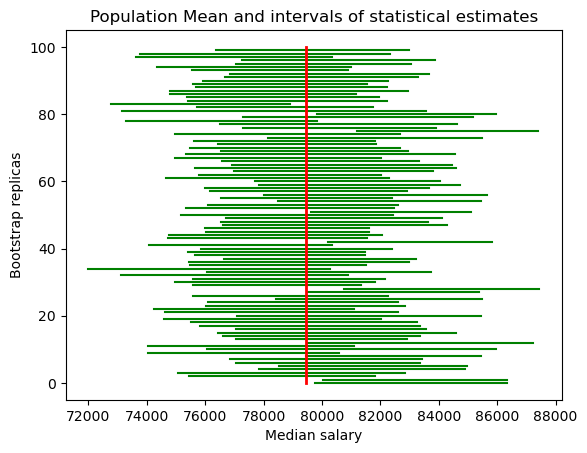

In [34]:
for i in np.arange(100):
    plt.plot([est_range[i,0], est_range[i,1]], [i, i], color = 'green')

plt.plot([pop_mdn, pop_mdn], [0, 100], color='red', lw=2)
plt.xlabel('Median salary')
plt.ylabel('Bootstrap replicas')
plt.title('Population Mean and intervals of statistical estimates')
plt.show()

### Read more at:
https://inferentialthinking.com/chapters/13/2/Bootstrap.html